# HW03: Distance and Topic Model

Remember that these homework work as a completion grade. **You can skip one section without losing credit.**

## Load and Pre-process Text

In [3]:
#Import the AG news dataset (same as hw01)
#Download them from here 
#!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 
df["text"] = df["title"] + " " + df["lead"]
df.head()

,label,title,lead,text
0,business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
1,business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
2,business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
3,business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."
4,business,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,"Stocks End Up, But Near Year Lows (Reuters) Re..."


In [4]:
import spacy
dfs = df.sample(200)
nlp = spacy.load('en_core_web_sm')
from sklearn.feature_extraction.text import TfidfVectorizer

#TODO preprocess the corpus using spacy
def preprocess(text):
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc
            if not token.is_punct and not token.is_stop and not token.is_digit and token.is_alpha]

# keep tokenized lists (needed for LDA later) and joined strings (needed for TF-IDF)
tokenized_docs = [preprocess(text) for text in dfs["text"]]
preprocessed_texts = [" ".join(tokens) for tokens in tokenized_docs]

##TODO vectorize the pre-processed text using TfidfVectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(preprocessed_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  (documents x vocab terms)")


TF-IDF matrix shape: (200, 2209)  (documents x vocab terms)


## Cosine Similarity and PCA

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

##TODO compute the cosine similarity for the first 200 snippets and for the first snippet, show the three most similar snippets and their respective cosine similarity scores
cos_sim = cosine_similarity(tfidf_matrix)  # shape: (200, 200)

# For the first snippet, rank all others by similarity (exclude itself at index 0)
first_sim_scores = cos_sim[0]
top3_indices = np.argsort(first_sim_scores)[::-1][1:4]  # skip rank 0 (itself)

print("First snippet:")
print(dfs["text"].iloc[0])
print("\nTop 3 most similar snippets:")
for rank, idx in enumerate(top3_indices, 1):
    print(f"\n  Rank {rank} (cosine similarity: {first_sim_scores[idx]:.4f}):")
    print(f"  {dfs['text'].iloc[idx]}")


First snippet:
David Jones Posts 2nd-Half Profit on Clothing Sales (Update1) David Jones Ltd., Australia #39;s second- largest department store, posted a second-half profit after increasing earnings at its credit card unit, selling more clothes and opening a store in Sydney #39;s Bondi Junction.

Top 3 most similar snippets:

  Rank 1 (cosine similarity: 0.1717):
  After adjusting, Pats get busy After a 3-3 slugfest of a first half, the New England Patriots (10-1) made enough alterations at the intermission to open the game up in the second half en route to a 24-3 win over Baltimore (7-4) yesterday.

  Rank 2 (cosine similarity: 0.1709):
  Supermarket chain Morrison sells 114 stores (AFP) AFP - William Morrison, the fourth largest grocery chain, said it had agreed to sell 114 stores to rival Somerfield for 260 million pounds.

  Rank 3 (cosine similarity: 0.1538):
  Avon Profit Up on International Sales  CHICAGO (Reuters) - Avon Products Inc. on Friday posted a  better-than-expected 33

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3, svd_solver='randomized')

##TODO reduce the vectorized data using PCA
# PCA requires a dense matrix; tfidf_matrix is sparse
tfidf_reduced = pca.fit_transform(tfidf_matrix.toarray())
print(f"Reduced matrix shape: {tfidf_reduced.shape}")

##TODO compute again cosine similarity with the reduced version for the first 200 snippets
cos_sim_pca = cosine_similarity(tfidf_reduced)

##TODO for the first snippet, show again its three most similar snippets
first_sim_pca = cos_sim_pca[0]
top3_pca = np.argsort(first_sim_pca)[::-1][1:4]

print("\nTop 3 most similar snippets after PCA reduction:")
for rank, idx in enumerate(top3_pca, 1):
    print(f"\n  Rank {rank} (cosine similarity: {first_sim_pca[idx]:.4f}):")
    print(f"  {dfs['text'].iloc[idx]}")


Reduced matrix shape: (200, 3)

Top 3 most similar snippets after PCA reduction:

  Rank 1 (cosine similarity: 0.9990):
  Tokyo Stocks Open Lower in Early Trading TOKYO - Tokyo stocks opened lower Tuesday after profit-taking weighed on Wall Street shares. The dollar rose against the Japanese yen.

  Rank 2 (cosine similarity: 0.9677):
  Stocks Open Lower; Oil Near \$50 a Barrel  NEW YORK (Reuters) - U.S. stocks opened lower on Tuesday  with oil prices holding near \$50 a barrel, while news that U.S.  gross domestic product grew at a stronger-than-expected pace in  the third quarter failed to create excitement on Wall Street.

  Rank 3 (cosine similarity: 0.9667):
  Fourtou: Vivendi Earnings Are Music To His Ears Finally, something to sing about at Vivendi Universal (nyse: V - news - people ). The French conglomerate raised its 2004 earnings forecast after reporting a fivefold increase in third-quarter profit, thanks to its music and telecommunications units.


Compare the cosine similarity before and after PCA reduction. Did the results change? 

## Clustering

In [14]:
# !pip install scikit-learn-extra
# from sklearn_extra.cluster import KMedoids  # skip: binary incompatibility in this env
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

##TODO create the clusters found with k-means clustering and 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)

score = silhouette_score(tfidf_matrix, kmeans_labels)
print(f"Silhouette score (k=5): {score:.4f}")

from collections import Counter
print("\nDocuments per cluster:")
for cluster, count in sorted(Counter(kmeans_labels).items()):
    print(f"  Cluster {cluster}: {count} documents")


Silhouette score (k=5): 0.0007

Documents per cluster:
  Cluster 0: 81 documents
  Cluster 1: 27 documents
  Cluster 2: 21 documents
  Cluster 3: 46 documents
  Cluster 4: 25 documents


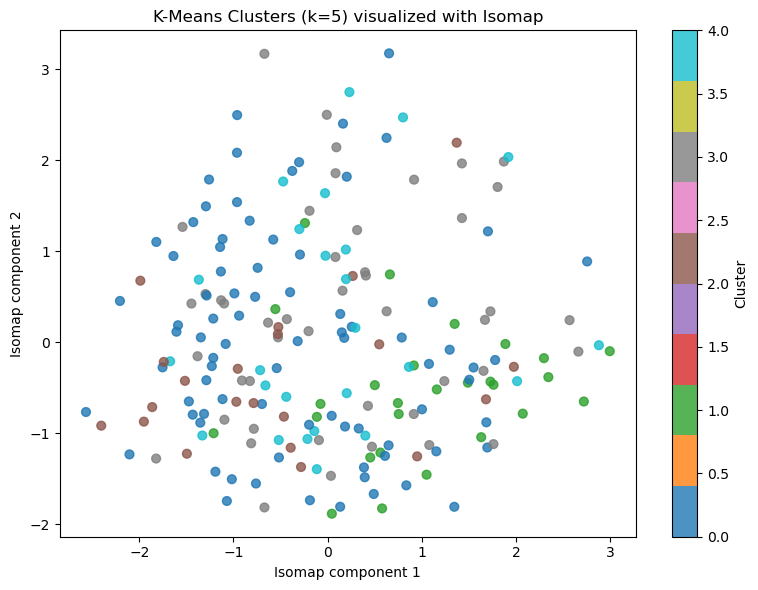

In [15]:
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap

##TODO visualize the k-means clustering results through Isomap (first reduce the dimensionality to 2 using Isomap, then use scatter plot (plt.scatter()) to visualize)
isomap = Isomap(n_components=2)
tfidf_2d = isomap.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c=kmeans_labels, cmap="tab10", s=40, alpha=0.8)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Clusters (k=5) visualized with Isomap")
plt.xlabel("Isomap component 1")
plt.ylabel("Isomap component 2")
plt.tight_layout()
plt.show()


## Topic Modeling: LDA

For this part you will need to use LDA Mallet. If you cannot have Mallet run, you can use the simple LDA algorithm 

In [17]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel          # LdaMallet wrapper removed in gensim 4.x
from gensim.models.coherencemodel import CoherenceModel

##TODO create a dictionary with the pre-processed tokenized text and filter it according to frequencies and keeping 1000 vocabularies
dictionary = Dictionary(tokenized_docs)
print(f"Dictionary size before filtering: {len(dictionary)}")

# remove tokens in fewer than 2 docs or more than 80% of docs, then cap at 1000
dictionary.filter_extremes(no_below=2, no_above=0.8, keep_n=1000)
print(f"Dictionary size after filtering: {len(dictionary)}")

##TODO create the doc_term_matrix
doc_term_matrix = [dictionary.doc2bow(tokens) for tokens in tokenized_docs]
print(f"Corpus: {len(doc_term_matrix)} documents")


Dictionary size before filtering: 2217
Dictionary size after filtering: 698
Corpus: 200 documents


In [18]:
##TODO train a LDA model with 5, 10 and 15 topics
##TODO compute the coherence score for each of these model and print the topics from the model with highest coherence score. Then find the optimal number of topics using the coherence score.

results = {}
for n_topics in [5, 10, 15]:
    model = LdaModel(
        corpus=doc_term_matrix,
        id2word=dictionary,
        num_topics=n_topics,
        random_state=42,
        passes=10,
    )
    coherence = CoherenceModel(
        model=model, texts=tokenized_docs, dictionary=dictionary, coherence="c_v"
    ).get_coherence()
    results[n_topics] = (model, coherence)
    print(f"Topics: {n_topics:2d}  |  Coherence (c_v): {coherence:.4f}")

# find optimal number of topics
best_n = max(results, key=lambda k: results[k][1])
best_model = results[best_n][0]
print(f"\nOptimal number of topics: {best_n} (coherence = {results[best_n][1]:.4f})")

print(f"\nTopics from best model (k={best_n}):")
for idx, topic in best_model.print_topics(num_words=10):
    print(f"  Topic {idx}: {topic}")


Topics:  5  |  Coherence (c_v): 0.4768
Topics: 10  |  Coherence (c_v): 0.4778
Topics: 15  |  Coherence (c_v): 0.4836

Optimal number of topics: 15 (coherence = 0.4836)

Topics from best model (k=15):
  Topic 0: 0.029*"year" + 0.016*"hit" + 0.016*"reuters" + 0.014*"afp" + 0.012*"soldier" + 0.012*"gather" + 0.012*"sunday" + 0.012*"official" + 0.012*"take" + 0.012*"report"
  Topic 1: 0.024*"new" + 0.018*"release" + 0.018*"state" + 0.018*"leave" + 0.018*"miss" + 0.018*"tokyo" + 0.012*"announce" + 0.012*"studio" + 0.012*"french" + 0.012*"group"
  Topic 2: 0.019*"reuters" + 0.016*"singapore" + 0.016*"million" + 0.013*"time" + 0.013*"prize" + 0.013*"win" + 0.013*"ap" + 0.013*"bush" + 0.010*"plan" + 0.010*"drug"
  Topic 3: 0.042*"say" + 0.030*"reuters" + 0.016*"year" + 0.014*"percent" + 0.014*"week" + 0.014*"windows" + 0.011*"new" + 0.011*"ap" + 0.011*"thursday" + 0.010*"monday"
  Topic 4: 0.038*"million" + 0.032*"cisco" + 0.019*"systems" + 0.019*"challenge" + 0.013*"week" + 0.013*"day" + 0.01

In [19]:
#!pip install pyLDAvis
# pyLDAvis.gensim was renamed to pyLDAvis.gensim_models in pyLDAvis 3.3+
# gensim.models.wrappers was removed in gensim 4.x — not needed here
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

##TODO using LDAvis visualize the topics using the optimal number of topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(best_model, doc_term_matrix, dictionary, sort_topics=False)
pyLDAvis.display(vis)

##TODO Interpret the topics. Is the coherence maximized model the one with the most interpretable topics?
# Answer in the markdown cell below.


**Topic interpretation:** *(fill in after running the visualization)*

**Is the coherence-maximized model the most interpretable?** Not necessarily. Coherence (c_v) measures statistical co-occurrence of top words, which tends to favor models with more topics since they can be more specific — but more topics also means more redundancy and overlap, making individual topics harder to label. A model with fewer, broader topics is often more interpretable even if its coherence score is slightly lower. The best practice is to use coherence as a guide to a shortlist of candidate k values, then inspect the topics qualitatively via pyLDAvis to make the final call.
